# Lesson 4.1 - Neural Networks & Backpropagation

## Learning Objectives
- Compare linear and nonlinear models on a toy nonlinear dataset.
- Understand one-step backpropagation numerically.
- Use a reusable debugging checklist for neural training.


## Setup and Reproducibility
We keep examples lightweight and deterministic so this notebook can run quickly in a standard environment.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Nonlinear Classification: Logistic Regression vs MLP


In [2]:
X, y = make_moons(n_samples=1200, noise=0.25, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

log_reg = LogisticRegression(max_iter=1000, random_state=SEED)
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu', max_iter=1200, random_state=SEED)

log_reg.fit(X_train, y_train)
mlp.fit(X_train, y_train)

pred_lr = log_reg.predict(X_test)
pred_mlp = mlp.predict(X_test)

metrics = {
    'log_reg_acc': accuracy_score(y_test, pred_lr),
    'log_reg_f1': f1_score(y_test, pred_lr),
    'mlp_acc': accuracy_score(y_test, pred_mlp),
    'mlp_f1': f1_score(y_test, pred_mlp),
}
print(metrics)


{'log_reg_acc': 0.8766666666666667, 'log_reg_f1': 0.872852233676976, 'mlp_acc': 0.95, 'mlp_f1': 0.9498327759197325}


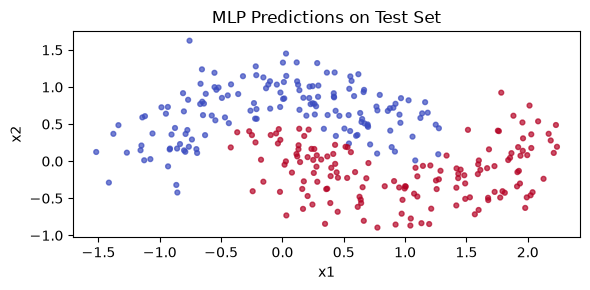

In [3]:
plt.figure(figsize=(6, 3))
plt.scatter(X_test[:, 0], X_test[:, 1], c=pred_mlp, cmap='coolwarm', s=12, alpha=0.7)
plt.title('MLP Predictions on Test Set')
plt.xlabel('x1')
plt.ylabel('x2')
plt.tight_layout()
plt.show()


## Tiny Backpropagation Step (NumPy)
This cell computes one gradient update for a one-hidden-layer network on a mini-batch.


In [4]:
Xb = X_train[:8]  # mini-batch
yb = y_train[:8].reshape(-1, 1)

# simple network sizes
in_dim, hidden_dim, out_dim = 2, 4, 1
W1 = np.random.randn(in_dim, hidden_dim) * 0.1
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, out_dim) * 0.1
b2 = np.zeros((1, out_dim))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# forward
z1 = Xb @ W1 + b1
a1 = np.maximum(0, z1)  # ReLU
z2 = a1 @ W2 + b2
y_hat = sigmoid(z2)

# binary cross-entropy gradient wrt logits
dz2 = y_hat - yb
dW2 = a1.T @ dz2 / len(Xb)
db2 = dz2.mean(axis=0, keepdims=True)
da1 = dz2 @ W2.T
dz1 = da1 * (z1 > 0)
dW1 = Xb.T @ dz1 / len(Xb)
db1 = dz1.mean(axis=0, keepdims=True)

lr = 0.1
W1 -= lr * dW1
b1 -= lr * db1
W2 -= lr * dW2
b2 -= lr * db2

print('mean_prediction_after_step:', float(sigmoid(np.maximum(0, Xb @ W1 + b1) @ W2 + b2).mean()))


mean_prediction_after_step: 0.5007591157982865


## Reusable Debugging Checklist
- [ ] Seed, split, and preprocessing are deterministic.
- [ ] Output activation and loss match the task.
- [ ] Baseline model comparison is documented.
- [ ] Gradients are finite (no NaN/Inf).
- [ ] Validation gap is monitored for overfitting.
- [ ] Rollback baseline is available.


## Case Studies & Exceptions
### Case 1: Better Offline Metric, Worse Product Outcome
A recommendation model increased click-through but reduced long-term retention because the loss optimized short-term behavior. Fix: revise objective and include long-term metrics.

### Case 2: Training Success, Serving Failure
A model worked in notebooks but failed in API due to inconsistent scaling. Fix: shared preprocessing module and contract tests.

### Exception
If a linear baseline already satisfies accuracy, latency, and interpretability requirements, a deep network may be unnecessary complexity.


## Interview Questions & Answers
1. **Q:** Why do neural networks need activation functions?  
   **A:** Without nonlinearity, stacked layers collapse to a linear model.
2. **Q:** What does backpropagation compute?  
   **A:** Gradients of loss with respect to each trainable parameter.
3. **Q:** Why compare against logistic regression?  
   **A:** It is a strong baseline and reveals whether nonlinearity adds real value.
4. **Q:** What causes exploding gradients?  
   **A:** Large update magnitudes through repeated multiplications in deep computation graphs.
5. **Q:** What is one practical overfitting signal?  
   **A:** Training improves while validation stagnates or worsens.
6. **Q:** Why set random seeds?  
   **A:** To make experiments reproducible and debuggable.
7. **Q:** Output activation for binary classification?  
   **A:** Sigmoid (with compatible loss).
8. **Q:** Why can deep models fail in production despite good offline metrics?  
   **A:** Data contract and preprocessing mismatches across environments.
9. **Q:** What is a safer first step before scaling network size?  
   **A:** Validate objective alignment and input pipeline correctness.
10. **Q:** When is deep learning not the right choice?  
   **A:** When simpler models meet constraints with lower operational risk.
